# Local Result Summary: `results/main/wav2vec`

Notebook này chỉ đọc kết quả nằm trong `results/main/wav2vec` và ghi bảng/plot vào `_summary/`.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    display
except NameError:
    def display(value):
        print(value)

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() or ((candidate / "configs").exists() and (candidate / "scripts").exists()):
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
SUMMARY_DIR = (PROJECT_ROOT / "results/main/wav2vec").resolve()
OUT_DIR = SUMMARY_DIR / "_summary"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["WA", "UA", "WF1", "Macro-F1"]
PRIMARY_METRIC = "Macro-F1"
EXPECTED_VARIANT_ORDER = ["baseline", "cdm", "cim", "cdm_cim"]

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SUMMARY_DIR  =", SUMMARY_DIR)
print("OUT_DIR      =", OUT_DIR)


PROJECT_ROOT = /home/jovyan/workspace/speech/conversational_ser
SUMMARY_DIR  = /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec
OUT_DIR      = /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec/_summary


## 2. Helpers


In [2]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def pct(value) -> float:
    if pd.isna(value):
        return np.nan
    return 100.0 * float(value)


def mean_std_text(mean, std) -> str:
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{pct(mean):.2f}"
    return f"{pct(mean):.2f} ± {pct(std):.2f}"


def relative_parts(path: Path) -> tuple[str, ...]:
    try:
        return path.relative_to(SUMMARY_DIR).parts
    except ValueError:
        return path.parts


TECHNICAL_SEGMENT_PATTERNS = (
    re.compile(r"^run_"),
    re.compile(r"^seed_"),
    re.compile(r"^test_Ses\d+$"),
)
TECHNICAL_SEGMENTS = {"cross_session", "phase_tests", "_summary", "cache"}


def clean_variant_parts(parts) -> list[str]:
    cleaned = []
    for part in parts:
        if part in TECHNICAL_SEGMENTS:
            continue
        if any(pattern.search(part) for pattern in TECHNICAL_SEGMENT_PATTERNS):
            continue
        if part.endswith(".json") or part.endswith(".csv") or part.endswith(".pth"):
            continue
        cleaned.append(part)
    return cleaned


def variant_from_cross_summary(path: Path) -> str:
    parts = list(relative_parts(path))
    stop_indices = [parts.index(token) for token in ["cross_session", "cross_session_summary.json"] if token in parts]
    end = min(stop_indices) if stop_indices else len(parts) - 1
    cleaned = clean_variant_parts(parts[:end])
    if cleaned:
        return "/".join(cleaned)
    return path.parent.name


def variant_from_metrics(path: Path) -> str:
    parts = list(relative_parts(path))
    stop_indices = [parts.index(token) for token in ["cross_session", "phase_tests", "metrics.json"] if token in parts]
    end = min(stop_indices) if stop_indices else len(parts) - 1
    cleaned = clean_variant_parts(parts[:end])
    if cleaned:
        return "/".join(cleaned)
    return path.parent.name


def run_id_from_path(path: Path) -> str:
    parts = relative_parts(path)
    for part in parts:
        if part.startswith("run_"):
            return part
    return "single_run"


def test_session_from_path(path: Path):
    match = re.search(r"test_Ses(\d+)", str(path))
    return int(match.group(1)) if match else np.nan


def flatten_metric_payload(payload: dict) -> dict:
    row = {}
    source = payload.get("test", payload)
    for metric in METRICS:
        value = source.get(metric, payload.get(metric))
        row[metric] = float(value) if value is not None else np.nan
    row["best_epoch"] = payload.get("best_epoch", payload.get("checkpoint_epoch", np.nan))
    return row


## 3. Cross-Session Aggregate


In [3]:
cross_rows = []
fold_rows = []
missing_fold_rows = []
for path in sorted(SUMMARY_DIR.rglob("cross_session_summary.json")):
    if "_summary" in relative_parts(path):
        continue
    payload = read_json(path)
    variant = variant_from_cross_summary(path)
    run_id = payload.get("run_name") or run_id_from_path(path)
    expected_sessions = [int(session) for session in payload.get("test_sessions", [])]
    observed_sessions = [int(fold.get("test_session", test_session_from_path(Path(str(fold.get("output_dir", "")))) or -1)) for fold in payload.get("folds", [])]
    for missing_session in sorted(set(expected_sessions) - set(observed_sessions)):
        missing_fold_rows.append({
            "variant": variant,
            "run_id": run_id,
            "missing_test_session": missing_session,
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        })
    row = {
        "variant": variant,
        "run_id": run_id,
        "trainer_module": payload.get("trainer_module", ""),
        "summary_path": str(path.relative_to(PROJECT_ROOT)),
    }
    aggregate = payload.get("aggregate", {})
    for metric in METRICS:
        stats = aggregate.get(metric, {}) if isinstance(aggregate, dict) else {}
        row[f"{metric}_mean"] = float(stats.get("mean", np.nan))
        row[f"{metric}_std"] = float(stats.get("std", np.nan))
        row[f"{metric}_n"] = int(stats.get("n", 0)) if not pd.isna(stats.get("n", np.nan)) else 0
    cross_rows.append(row)

    for fold in payload.get("folds", []):
        metrics = fold.get("metrics", {})
        fold_row = {
            "variant": variant,
            "run_id": run_id,
            "test_session": int(fold.get("test_session", test_session_from_path(Path(str(fold.get("output_dir", "")))) or -1)),
            "output_dir": fold.get("output_dir", ""),
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        }
        for metric in METRICS:
            fold_row[metric] = float(metrics.get(metric, np.nan))
        fold_rows.append(fold_row)

aggregate_df = pd.DataFrame(cross_rows)
folds_df = pd.DataFrame(fold_rows)
missing_folds_df = pd.DataFrame(missing_fold_rows)

if not aggregate_df.empty:
    aggregate_df = aggregate_df.sort_values(f"{PRIMARY_METRIC}_mean", ascending=False).reset_index(drop=True)
    aggregate_df.to_csv(OUT_DIR / "cross_session_aggregate.csv", index=False)
if not folds_df.empty:
    folds_df = folds_df.sort_values(["variant", "run_id", "test_session"]).reset_index(drop=True)
    folds_df.to_csv(OUT_DIR / "cross_session_folds.csv", index=False)
if not missing_folds_df.empty:
    missing_folds_df = missing_folds_df.sort_values(["variant", "run_id", "missing_test_session"]).reset_index(drop=True)
missing_folds_df.to_csv(OUT_DIR / "missing_cross_session_folds.csv", index=False)

print(f"Found {len(aggregate_df)} cross-session summaries and {len(folds_df)} folds")
if missing_folds_df.empty:
    print("No missing folds reported by cross-session summaries.")
else:
    print(f"Missing {len(missing_folds_df)} expected fold(s); see missing_cross_session_folds.csv")
    display(missing_folds_df)
if aggregate_df.empty:
    print("No cross_session_summary.json files found under", SUMMARY_DIR)
else:
    display(aggregate_df)


Found 4 cross-session summaries and 20 folds
No missing folds reported by cross-session summaries.


,variant,run_id,trainer_module,summary_path,WA_mean,WA_std,WA_n,UA_mean,UA_std,UA_n,WF1_mean,WF1_std,WF1_n,Macro-F1_mean,Macro-F1_std,Macro-F1_n
0,cdm,run_20260704_040025,scripts.train_wavlm_cdm,results/main/wav2vec/cdm/cross_session/run_202...,0.532169,0.031422,5,0.496632,0.056675,5,0.501293,0.033010,5,0.474970,0.047101,5
1,cdm_cim,run_20260704_063652,scripts.train_dual_branch,results/main/wav2vec/cdm_cim/cross_session/run...,0.519431,0.037299,5,0.491271,0.048661,5,0.486116,0.043640,5,0.466752,0.034365,5
2,cim,run_20260704_050047,scripts.train_dual_branch,results/main/wav2vec/cim/cross_session/run_202...,0.484589,0.054270,5,0.441344,0.022749,5,0.447199,0.075075,5,0.419581,0.039094,5
3,baseline,run_20260704_035620,scripts.train_wavlm_baseline,results/main/wav2vec/baseline/cross_session/ru...,0.462341,0.061685,5,0.390977,0.028155,5,0.378308,0.066713,5,0.337161,0.029252,5


## 4. Mean ± Std Table


In [4]:
if aggregate_df.empty:
    formatted_df = pd.DataFrame()
else:
    formatted_rows = []
    for _, row in aggregate_df.iterrows():
        item = {
            "variant": row["variant"],
            "run_id": row["run_id"],
            "trainer_module": row.get("trainer_module", ""),
        }
        for metric in METRICS:
            item[metric] = mean_std_text(row.get(f"{metric}_mean", np.nan), row.get(f"{metric}_std", np.nan))
        formatted_rows.append(item)
    formatted_df = pd.DataFrame(formatted_rows)
    formatted_df.to_csv(OUT_DIR / "cross_session_aggregate_formatted.csv", index=False)
    display(formatted_df)


,variant,run_id,trainer_module,WA,UA,WF1,Macro-F1
0,cdm,run_20260704_040025,scripts.train_wavlm_cdm,53.22 ± 3.14,49.66 ± 5.67,50.13 ± 3.30,47.50 ± 4.71
1,cdm_cim,run_20260704_063652,scripts.train_dual_branch,51.94 ± 3.73,49.13 ± 4.87,48.61 ± 4.36,46.68 ± 3.44
2,cim,run_20260704_050047,scripts.train_dual_branch,48.46 ± 5.43,44.13 ± 2.27,44.72 ± 7.51,41.96 ± 3.91
3,baseline,run_20260704_035620,scripts.train_wavlm_baseline,46.23 ± 6.17,39.10 ± 2.82,37.83 ± 6.67,33.72 ± 2.93


## 5. Mean Metrics Heatmap


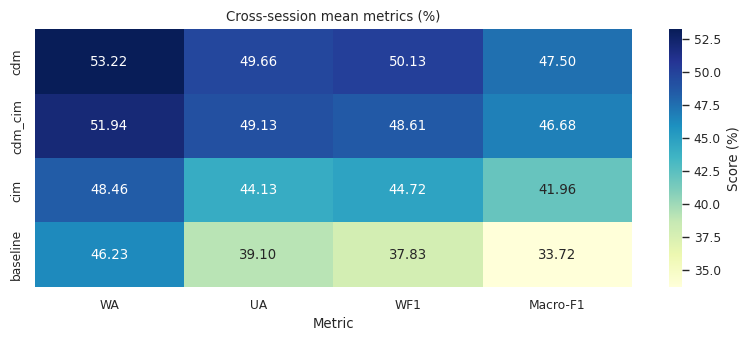

Saved /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec/_summary/figures/cross_session_mean_metrics_heatmap.png


In [5]:
if aggregate_df.empty:
    print("No aggregate data for mean-metrics heatmap.")
else:
    metric_cols = [f"{metric}_mean" for metric in METRICS if f"{metric}_mean" in aggregate_df.columns]
    mean_heat = aggregate_df.set_index("variant")[metric_cols].rename(columns={f"{metric}_mean": metric for metric in METRICS}) * 100.0
    metric_order = [metric for metric in METRICS if metric in mean_heat.columns]
    sort_metric = PRIMARY_METRIC if PRIMARY_METRIC in mean_heat.columns else metric_order[0]
    mean_heat = mean_heat[metric_order].sort_values(sort_metric, ascending=False)
    mean_heat.to_csv(OUT_DIR / "cross_session_mean_metrics_heatmap.csv")
    plt.figure(figsize=(max(7, 1.0 * mean_heat.shape[1] + 4), max(3.5, 0.45 * len(mean_heat) + 1.5)))
    sns.heatmap(mean_heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Score (%)"})
    plt.title("Cross-session mean metrics (%)")
    plt.xlabel("Metric")
    plt.ylabel("")
    plt.tight_layout()
    fig_path = FIG_DIR / "cross_session_mean_metrics_heatmap.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", fig_path)


## 5. Session Heatmap


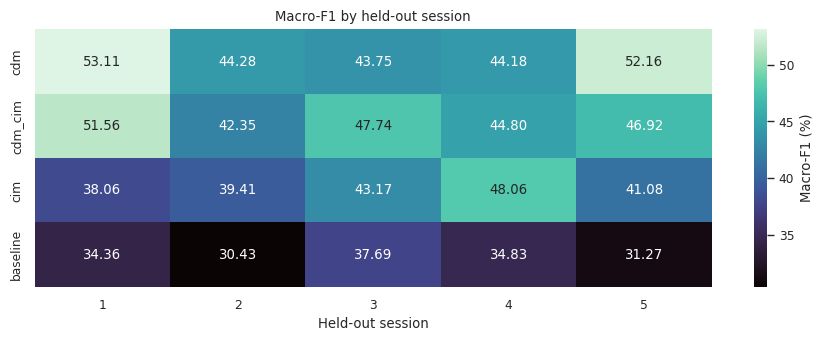

Saved /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec/_summary/figures/cross_session_heatmap.png


In [6]:
if folds_df.empty:
    print("No fold-level data for heatmap.")
else:
    pivot = folds_df.pivot_table(
        index="variant",
        columns="test_session",
        values=PRIMARY_METRIC,
        aggfunc="max",
    )
    present_variants = set(aggregate_df["variant"].drop_duplicates().tolist()) | set(pivot.index.tolist())
    variant_order = [variant for variant in aggregate_df["variant"].drop_duplicates().tolist() if variant in present_variants]
    variant_order.extend(sorted(variant for variant in present_variants if variant not in variant_order))
    pivot = pivot.reindex(variant_order)
    plt.figure(figsize=(max(7, 1.0 * pivot.shape[1] + 4), max(3.5, 0.45 * len(pivot) + 1.5)))
    sns.heatmap(pivot * 100.0, annot=True, fmt=".2f", cmap="mako", cbar_kws={"label": f"{PRIMARY_METRIC} (%)"})
    plt.title(f"{PRIMARY_METRIC} by held-out session")
    plt.xlabel("Held-out session")
    plt.ylabel("")
    plt.tight_layout()
    fig_path = FIG_DIR / "cross_session_heatmap.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", fig_path)


## 6. Standalone Metrics


In [7]:
single_rows = []
for path in sorted(SUMMARY_DIR.rglob("metrics.json")):
    parts = set(relative_parts(path))
    if "_summary" in parts:
        continue
    if "phase_tests" in parts:
        continue
    if "cross_session" in parts:
        # Fold metrics are already represented by cross_session_summary.json.
        continue
    payload = read_json(path)
    row = {
        "variant": variant_from_metrics(path),
        "run_id": run_id_from_path(path),
        "metrics_path": str(path.relative_to(PROJECT_ROOT)),
    }
    row.update(flatten_metric_payload(payload))
    single_rows.append(row)

single_metrics_df = pd.DataFrame(single_rows)
if not single_metrics_df.empty:
    single_metrics_df = single_metrics_df.sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
    single_metrics_df.to_csv(OUT_DIR / "single_run_metrics.csv", index=False)
    display(single_metrics_df)
else:
    print("No standalone metrics.json files found outside cross_session folds.")


No standalone metrics.json files found outside cross_session folds.


## 7. Phase Test Metrics


In [8]:
phase_rows = []
for path in sorted(SUMMARY_DIR.rglob("phase_test_metrics.csv")):
    if "_summary" in relative_parts(path):
        continue
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        print("Failed to read", path, exc)
        continue
    variant = variant_from_metrics(path)
    run_id = run_id_from_path(path)
    for _, row in df.iterrows():
        item = row.to_dict()
        item.update({
            "variant": variant,
            "run_id": run_id,
            "phase_metrics_path": str(path.relative_to(PROJECT_ROOT)),
        })
        phase_rows.append(item)

phase_df = pd.DataFrame(phase_rows)
if not phase_df.empty:
    metric_col = "test_Macro-F1" if "test_Macro-F1" in phase_df.columns else None
    if metric_col:
        phase_df = phase_df.sort_values(metric_col, ascending=False).reset_index(drop=True)
    phase_df.to_csv(OUT_DIR / "phase_test_metrics.csv", index=False)
    display(phase_df)
else:
    print("No phase_test_metrics.csv files found.")


,phase,checkpoint_epoch,validation_UA,test_WA,test_UA,test_WF1,test_Macro-F1,checkpoint,variant,run_id,phase_metrics_path
0,end_to_end,106,0.596093,0.528867,0.561181,0.527582,0.515618,results/main/wav2vec/cdm_cim/cross_session/run...,cdm_cim,run_20260704_063652,results/main/wav2vec/cdm_cim/cross_session/run...
1,end_to_end,111,0.515586,0.578023,0.475403,0.570361,0.480602,results/main/wav2vec/cim/cross_session/run_202...,cim,run_20260704_050047,results/main/wav2vec/cim/cross_session/run_202...
2,end_to_end,82,0.578737,0.507673,0.484737,0.499566,0.477359,results/main/wav2vec/cdm_cim/cross_session/run...,cdm_cim,run_20260704_063652,results/main/wav2vec/cdm_cim/cross_session/run...
3,end_to_end,56,0.564484,0.512121,0.515862,0.457530,0.469211,results/main/wav2vec/cdm_cim/cross_session/run...,cdm_cim,run_20260704_063652,results/main/wav2vec/cdm_cim/cross_session/run...
4,end_to_end,84,0.541805,0.575423,0.453089,0.520668,0.448021,results/main/wav2vec/cdm_cim/cross_session/run...,cdm_cim,run_20260704_063652,results/main/wav2vec/cdm_cim/cross_session/run...
5,end_to_end,55,0.452270,0.471228,0.428133,0.467912,0.431726,results/main/wav2vec/cim/cross_session/run_202...,cim,run_20260704_050047,results/main/wav2vec/cim/cross_session/run_202...
6,end_to_end,41,0.528778,0.473071,0.441484,0.425234,0.423549,results/main/wav2vec/cdm_cim/cross_session/run...,cdm_cim,run_20260704_063652,results/main/wav2vec/cdm_cim/cross_session/run...
7,end_to_end,76,0.436717,0.463030,0.443419,0.403629,0.410847,results/main/wav2vec/cim/cross_session/run_202...,cim,run_20260704_050047,results/main/wav2vec/cim/cross_session/run_202...
8,end_to_end,72,0.505105,0.436681,0.414579,0.394009,0.394085,results/main/wav2vec/cim/cross_session/run_202...,cim,run_20260704_050047,results/main/wav2vec/cim/cross_session/run_202...
9,end_to_end,29,0.417076,0.473984,0.445189,0.400083,0.380645,results/main/wav2vec/cim/cross_session/run_202...,cim,run_20260704_050047,results/main/wav2vec/cim/cross_session/run_202...


## 8. Prediction Files


In [9]:
prediction_rows = []
for path in sorted(SUMMARY_DIR.rglob("predictions.csv")):
    if "_summary" in relative_parts(path):
        continue
    prediction_rows.append({
        "variant": variant_from_metrics(path),
        "run_id": run_id_from_path(path),
        "test_session": test_session_from_path(path),
        "prediction_path": str(path.relative_to(PROJECT_ROOT)),
    })

prediction_df = pd.DataFrame(prediction_rows)
if not prediction_df.empty:
    prediction_df.to_csv(OUT_DIR / "prediction_file_index.csv", index=False)
    display(prediction_df.head(50))
    print(f"Prediction files: {len(prediction_df)}")
else:
    print("No predictions.csv files found.")


,variant,run_id,test_session,prediction_path
0,baseline,run_20260704_035620,1,results/main/wav2vec/baseline/cross_session/ru...
1,baseline,run_20260704_035620,2,results/main/wav2vec/baseline/cross_session/ru...
2,baseline,run_20260704_035620,3,results/main/wav2vec/baseline/cross_session/ru...
3,baseline,run_20260704_035620,4,results/main/wav2vec/baseline/cross_session/ru...
4,baseline,run_20260704_035620,5,results/main/wav2vec/baseline/cross_session/ru...
5,cdm,run_20260704_040025,1,results/main/wav2vec/cdm/cross_session/run_202...
6,cdm,run_20260704_040025,2,results/main/wav2vec/cdm/cross_session/run_202...
7,cdm,run_20260704_040025,3,results/main/wav2vec/cdm/cross_session/run_202...
8,cdm,run_20260704_040025,4,results/main/wav2vec/cdm/cross_session/run_202...
9,cdm,run_20260704_040025,5,results/main/wav2vec/cdm/cross_session/run_202...


Prediction files: 30


## 9. Report


In [10]:
def dataframe_report(frame: pd.DataFrame) -> str:
    try:
        return frame.to_markdown(index=False)
    except ImportError:
        return "```\n" + frame.to_string(index=False) + "\n```"


report = [
    f"# Local Result Summary: `{SUMMARY_DIR.relative_to(PROJECT_ROOT)}`",
    "",
    f"- Cross-session summaries: {len(aggregate_df)}",
    f"- Cross-session folds: {len(folds_df)}",
    f"- Standalone metric files: {len(single_metrics_df)}",
    f"- Phase metric rows: {len(phase_df)}",
    f"- Prediction files: {len(prediction_df)}",
    "",
]
if not formatted_df.empty:
    report.extend(["## Cross-Session Aggregate", "", dataframe_report(formatted_df), ""])
if not single_metrics_df.empty:
    report.extend(["## Standalone Metrics", "", dataframe_report(single_metrics_df), ""])
if not phase_df.empty:
    report.extend(["## Phase Test Metrics", "", dataframe_report(phase_df), ""])

report_path = OUT_DIR / "summary.md"
report_path.write_text("\n".join(report) + "\n", encoding="utf-8")
print("Saved", report_path)


Saved /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec/_summary/summary.md


## 10. Saved Outputs


In [11]:
outputs = sorted(p.relative_to(OUT_DIR) for p in OUT_DIR.rglob("*") if p.is_file())
print(f"Saved {len(outputs)} files under {OUT_DIR}")
for path in outputs:
    print(path)


Saved 10 files under /home/jovyan/workspace/speech/conversational_ser/results/main/wav2vec/_summary
cross_session_aggregate.csv
cross_session_aggregate_formatted.csv
cross_session_folds.csv
cross_session_mean_metrics_heatmap.csv
figures/cross_session_heatmap.png
figures/cross_session_mean_metrics_heatmap.png
missing_cross_session_folds.csv
phase_test_metrics.csv
prediction_file_index.csv
summary.md
